# Custom inventory policies

This tutorial implements a small reorder rule as a `BasePolicy` subclass and runs it through Pyforia's simulation engine. The policy decides what to request; the engine still owns demand processing, lead-time transitions, inventory mutation, and canonical events.

The rule is deliberately transparent: when inventory position is at or below a declared threshold, request a declared fixed quantity. Inventory position is **on-hand + pipeline - backorders**, so the policy accounts for stock already on its way instead of ordering from physical stock alone.

Both the threshold and quantity are scenario inputs. Pyforia does not infer them from demand or manufacture a forecast target. In a real workflow they might come from business rules or a separately recorded forecast-to-decision calculation.

In [1]:
import math

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from pyforia import (
    BasePolicy, InventoryStateDataFrame, OrderDecision, SimulationEngine,
)
from pyforia.evaluation import (
    InventoryEvaluator, avg_on_hand, demand_period_service_level,
    fill_rate, order_units,
)

## 1. Define the policy contract

A custom policy implements `fit()` and `predict()`, marks itself fitted, and returns an `OrderDecision` with valid timing. Here, `fit()` simply confirms that the declared operating parameters are ready; there is no forecast table to estimate.

`predict()` receives inventory state as a read-only input. Its output says what the policy requests and when that request should arrive. It does not edit on-hand stock or the pipeline itself.

In [2]:
class ReorderWhenBelowPolicy(BasePolicy):
    """Request a fixed quantity when inventory position reaches a threshold."""

    def __init__(
        self, reorder_threshold, order_quantity, parameter_source, **kwargs,
    ):
        super().__init__(**kwargs)
        # Fail early before an invalid operating input reaches the engine.
        self.reorder_threshold = float(reorder_threshold)
        self.order_quantity = float(order_quantity)
        if not math.isfinite(self.reorder_threshold) or self.reorder_threshold < 0:
            raise ValueError('reorder_threshold must be finite and non-negative')
        if not math.isfinite(self.order_quantity) or self.order_quantity <= 0:
            raise ValueError('order_quantity must be finite and positive')
        if not isinstance(parameter_source, str) or not parameter_source.strip():
            raise ValueError('parameter_source must be a non-empty string')
        self.parameter_source = parameter_source.strip()

    def fit(self, forecast_df=None, **kwargs):
        # This rule uses declared operating inputs, not a fitted forecast target.
        self.fitted_ = True
        return self

    def predict(self, inventory_state_df, current_period=0, **kwargs):
        if not self.fitted_:
            raise ValueError('policy must be fitted before prediction')

        # inventory_position() returns a table; no live inventory values are changed.
        positions = inventory_state_df.inventory_position()
        sku_column = inventory_state_df.sku_column
        decision = positions[[sku_column, 'inventory_position']].copy()
        # The boolean trigger becomes 1.0 or 0.0 for every SKU row.
        decision['order_quantity'] = (
            decision['inventory_position'].le(self.reorder_threshold).astype(float)
            * self.order_quantity
        )
        # This is a fixed-quantity rule, so an order-up-to target is not applicable.
        decision['target_level'] = math.nan
        decision['reorder_point'] = self.reorder_threshold
        # Timing metadata must agree with the policy's physical lead time.
        decision['order_period'] = current_period
        decision['expected_delivery_period'] = current_period + self.lead_time
        return OrderDecision(
            decision[[
                sku_column, 'order_quantity', 'target_level',
                'inventory_position', 'reorder_point', 'order_period',
                'expected_delivery_period',
            ]],
            sku_column=sku_column,
            lead_time=self.lead_time,
            review_period=self.review_period,
        )


## 2. Declare the scenario

The policy checks inventory position every day. Orders take two days to arrive, and unmet demand is treated as lost sales. The opening decision is explicit rather than inferred from the first demand row.

Opening stock equals the threshold, making the first positive decision easy to inspect. The short repeating demand path then lets the threshold be crossed again after receipts and consumption. These values make the mechanics visible; they are not calibrated recommendations.

In [3]:
sku = 'widget_A'
opening_date = pd.Timestamp('2026-03-01')
period_frequency = 'D'
lead_time = 2
review_period = 1
reorder_threshold = 6.0
fixed_order_quantity = 10.0
initial_decision = 'before_first_demand'
demand_source_name = 'declared_custom_policy_scenario'
random_seed = None


In [4]:
# service_level=None is explicit because this rule has no probabilistic target.
policy = ReorderWhenBelowPolicy(
    reorder_threshold=reorder_threshold,
    order_quantity=fixed_order_quantity,
    parameter_source='declared_scenario_input',
    lead_time=lead_time,
    review_period=review_period,
    service_level=None,
    allow_backorders=False,
).fit()

configuration = pd.DataFrame([{
    'policy': policy.policy_name,
    'fitted': policy.fitted_,
    'reorder_threshold': reorder_threshold,
    'order_quantity': fixed_order_quantity,
    'parameter_source': policy.parameter_source,
    'lead_time': lead_time,
    'review_period': review_period,
    'initial_decision': initial_decision,
    'allow_backorders': policy.allow_backorders,
}])
print(configuration.to_string(index=False))


                policy  fitted  reorder_threshold  order_quantity        parameter_source  lead_time  review_period    initial_decision  allow_backorders
ReorderWhenBelowPolicy    True                6.0            10.0 declared_scenario_input          2              1 before_first_demand             False


In [5]:
# Opening stock equals the threshold, making the first decision easy to inspect.
opening_stock = pd.DataFrame({
    'unique_id': [sku],
    'observed_on_hand': [6.0],
})
opening_stock


,unique_id,observed_on_hand
0,widget_A,6.0


In [6]:
# The pipeline must have room for every slot in the declared lead time.
# The engine will deep-copy this state; the caller-owned object stays unchanged.
opening_inventory = InventoryStateDataFrame(
    [sku], max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    opening_stock,
    on_hand_column='observed_on_hand',
    start_date=opening_date,
)
opening_inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=6, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [7]:
opening_view = opening_inventory.inventory_position()
print('Opening state')
print(opening_view[[
    'unique_id', 'date', 'period', 'on_hand', 'backorders',
    'total_in_transit', 'inventory_position',
]].to_string(index=False))


Opening state
unique_id       date  period  on_hand  backorders  total_in_transit  inventory_position
 widget_A 2026-03-01     0.0      6.0         0.0               0.0                 6.0


In [8]:
demand_values = [2.0, 3.0, 4.0, 2.0, 3.0, 4.0, 2.0, 3.0, 4.0, 2.0]
# The engine requires one dated row for every SKU-period combination.
demand = pd.DataFrame({
    'unique_id': [sku] * len(demand_values),
    'period': range(len(demand_values)),
    'date': pd.date_range(
        opening_date + pd.Timedelta(days=1),
        periods=len(demand_values),
        freq=period_frequency,
    ),
    'y': demand_values,
})


In [9]:
# Ten dated rows begin the day after the opening state; the short repeating
# path lets the threshold trigger several review decisions in view.
assert len(demand) == len(demand_values)
assert demand[['unique_id', 'period']].duplicated().sum() == 0
assert demand['date'].min() == opening_date + pd.Timedelta(days=1)

print('Declared demand')
print(demand.to_string(index=False))


Declared demand
unique_id  period       date   y
 widget_A       0 2026-03-02 2.0
 widget_A       1 2026-03-03 3.0
 widget_A       2 2026-03-04 4.0
 widget_A       3 2026-03-05 2.0
 widget_A       4 2026-03-06 3.0
 widget_A       5 2026-03-07 4.0
 widget_A       6 2026-03-08 2.0
 widget_A       7 2026-03-09 3.0
 widget_A       8 2026-03-10 4.0
 widget_A       9 2026-03-11 2.0


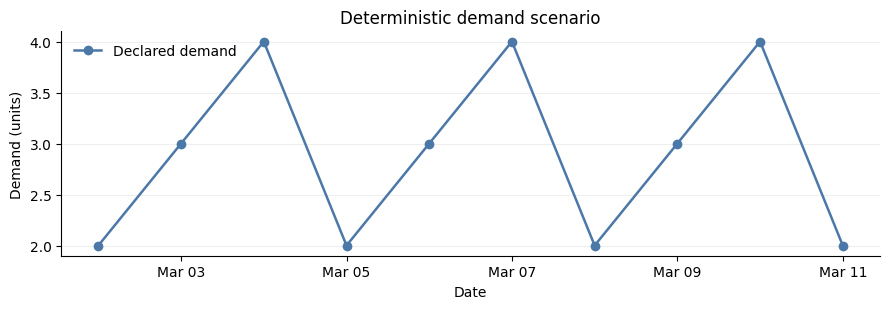

In [10]:
# Plot the repeating path before the policy ever sees it.
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(demand['date'], demand['y'], marker='o', linewidth=1.8, color='#4C78A8',
        label='Declared demand')
ax.set(title='Deterministic demand scenario', xlabel='Date', ylabel='Demand (units)')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


## 3. Inspect one decision

Opening inventory position equals the threshold, so the policy requests 10 units. The decision table keeps the state used by the rule (`inventory_position`), its trigger (`reorder_point`), the requested quantity, and delivery timing together.

The expected delivery period is the order period plus the two-day lead time. `target_level` is intentionally empty because this policy requests a fixed quantity rather than ordering up to a target.

In [11]:
# Compare defensive copies before and after predict() to show read-only behavior.
state_before_prediction = opening_inventory.get_dataframe()
opening_decision = policy.predict(opening_inventory, current_period=0)
state_after_prediction = opening_inventory.get_dataframe()

print('Order decision')
print(opening_decision.get_dataframe().to_string(index=False))
print(f'\nInventory unchanged by predict(): {state_before_prediction.equals(state_after_prediction)}')

assert state_before_prediction.equals(state_after_prediction)


Order decision
unique_id  order_quantity  target_level  inventory_position  reorder_point  order_period  expected_delivery_period
 widget_A            10.0           NaN                 6.0            6.0             0                         2

Inventory unchanged by predict(): True


## 4. Let the engine run the policy

The engine first copies the caller's inventory and policy, so the run owns its mutable working state. It applies the explicit opening decision, then repeats the standard period sequence: receive due pipeline stock, process demand, call the policy on an eligible review period, place accepted orders into the pipeline, and validate the event row.

All ten periods are scoring periods here. There is no warm-up or settlement tail because the example focuses only on the custom decision path.

In [12]:
# A complete engine run keeps timing, windows, provenance, and demand explicit.
result = SimulationEngine().run(
    policy=policy,
    demand_source=demand,
    inventory=opening_inventory,
    n_periods=len(demand),
    period_frequency=period_frequency,
    initial_decision=initial_decision,
    warmup_periods=0,
    scoring_periods=len(demand),
    settlement_periods=0,
    order_during_settlement=False,
    demand_source_name=demand_source_name,
    random_seed=random_seed,
)

In [13]:
# The engine owns this state; the caller-owned `opening_inventory` above is unchanged.
result.inventory


InventoryStateDataFrame(n_skus=1, total_on_hand=7, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

The opening event proves that placing 10 units leaves on-hand at 6 while pipeline stock becomes 10. Physical stock changes only when that order is received two periods later.

Canonical period events record the end-of-period inventory position after any accepted order. In this unconstrained, callback-free scenario, subtracting `order_quantity` recovers the pre-order position read by the policy. That derived column makes each observed trigger directly comparable with the declared rule.

In [14]:
events = result.to_event_frame(window='all')
opening_event = events.loc[events['event_type'].eq('initial_decision')].copy()
period_events = events.loc[events['event_type'].eq('period')].copy()
# With no callbacks or constraints, the accepted quantity is the policy request.
period_events['pre_order_inventory_position'] = (
    period_events['inventory_position_end'] - period_events['order_quantity']
)
period_events['rule_triggered'] = (
    period_events['pre_order_inventory_position'] <= reorder_threshold
)

print(f"Engine events: {len(events)} rows (one opening decision plus ten demand periods)")
print('\nEngine-owned opening-order event')
print(opening_event[[
    'event_type', 'date', 'order_quantity', 'ending_on_hand', 'on_order_end',
]].to_string(index=False))


Engine events: 11 rows (one opening decision plus ten demand periods)

Engine-owned opening-order event
      event_type       date  order_quantity  ending_on_hand  on_order_end
initial_decision 2026-03-01            10.0             6.0          10.0


In [15]:
print('Period event evidence')
print(period_events[[
    'date', 'demand', 'pre_order_inventory_position', 'rule_triggered',
    'order_quantity', 'received_units', 'ending_on_hand', 'on_order_end',
    'shortage_units',
]].round(3).to_string(index=False))


Period event evidence
      date  demand  pre_order_inventory_position  rule_triggered  order_quantity  received_units  ending_on_hand  on_order_end  shortage_units
2026-03-02     2.0                          14.0           False             0.0             0.0             4.0          10.0             0.0
2026-03-03     3.0                          11.0           False             0.0            10.0            11.0           0.0             0.0
2026-03-04     4.0                           7.0           False             0.0             0.0             7.0           0.0             0.0
2026-03-05     2.0                           5.0            True            10.0             0.0             5.0          10.0             0.0
2026-03-06     3.0                          12.0           False             0.0             0.0             2.0          10.0             0.0
2026-03-07     4.0                           8.0           False             0.0            10.0             8.0        

In [16]:
# Metrics read validated scoring events, not mutable inventory snapshots.
metrics = InventoryEvaluator().fit(
    simulation_result=result, window='scoring',
).evaluate(
    metrics=[fill_rate, demand_period_service_level, avg_on_hand, order_units],
    groupby=[],  # Pool this one-SKU scenario into one result row.
)
print('Scoring-window metrics')
print(metrics.round(3).to_string(index=False))

# Separate engine-recorded operating settings from custom scenario evidence.
manifest_policy = result.run_manifest['policy']
manifest_view = pd.DataFrame([{
    'class': manifest_policy['class'],
    'lead_time': manifest_policy['lead_time'],
    'review_period': manifest_policy['review_period'],
    'service_level': manifest_policy['service_level'],
    'allow_backorders': manifest_policy['allow_backorders'],
}])
print('\nEngine manifest policy settings')
print(manifest_view.to_string(index=False))
print('\nCustom inputs kept as explicit scenario evidence')
print(configuration[[
    'reorder_threshold', 'order_quantity', 'parameter_source',
]].to_string(index=False))

Scoring-window metrics
 fill_rate  demand_period_service_level  avg_on_hand  order_units
       1.0                          1.0          6.2         30.0

Engine manifest policy settings
                 class  lead_time  review_period service_level  allow_backorders
ReorderWhenBelowPolicy          2              1          None             False

Custom inputs kept as explicit scenario evidence
 reorder_threshold  order_quantity        parameter_source
               6.0            10.0 declared_scenario_input


## 5. See the rule and its inventory consequences

The first panel checks the decision rule: red markers occur only where pre-order inventory position reaches or falls below the dashed threshold. The second panel separates requests from receipts, making the two-period delay visible. The third distinguishes usable on-hand stock from units still in transit.

The opening order is already in transit when the first demand period begins, so its later receipt appears even though its order marker belongs to the separate opening-decision event.

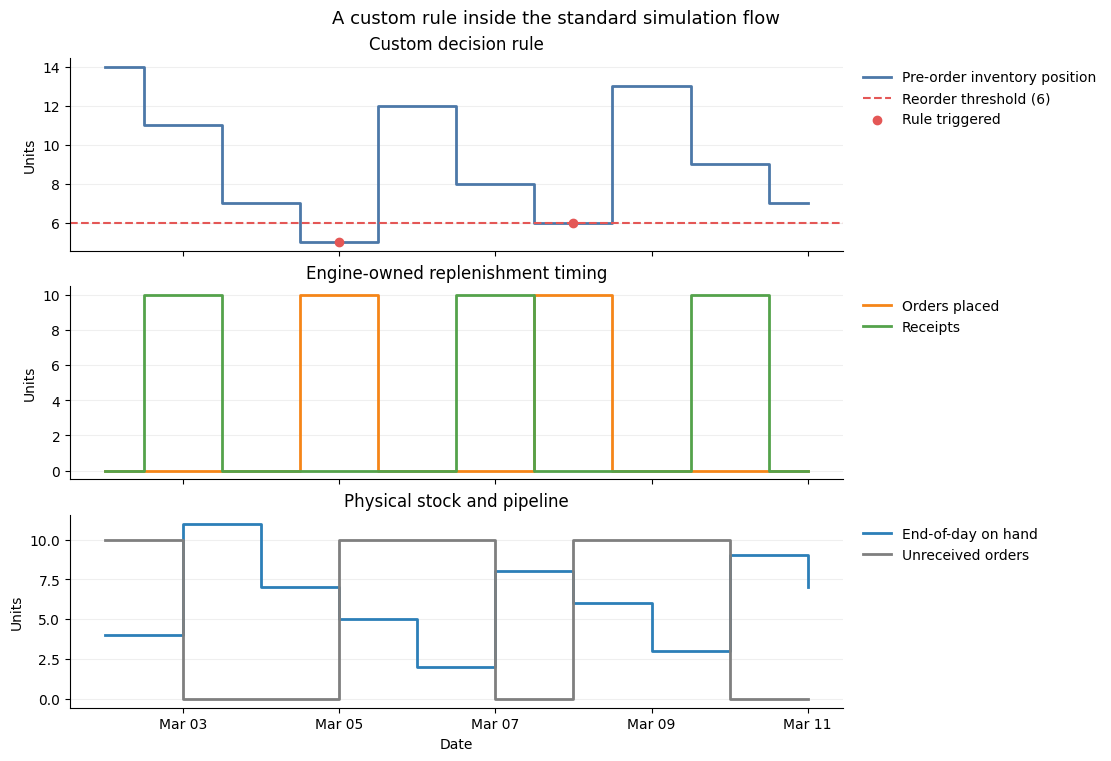

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True, layout='constrained')

# Step lines suit values that remain in effect over discrete inventory periods.
axes[0].step(
    period_events['date'], period_events['pre_order_inventory_position'],
    where='mid', linewidth=2, color='#4C78A8', label='Pre-order inventory position',
)
axes[0].axhline(
    reorder_threshold, color='#E45756', linestyle='--',
    label=f'Reorder threshold ({reorder_threshold:g})',
)
triggered = period_events.loc[period_events['rule_triggered']]
axes[0].scatter(
    triggered['date'], triggered['pre_order_inventory_position'],
    color='#E45756', zorder=3, label='Rule triggered',
)
axes[0].set(title='Custom decision rule', ylabel='Units')

axes[1].step(
    period_events['date'], period_events['order_quantity'], where='mid',
    linewidth=2, color='#F58518', label='Orders placed',
)
axes[1].step(
    period_events['date'], period_events['received_units'], where='mid',
    linewidth=2, color='#54A24B', label='Receipts',
)
axes[1].set(title='Engine-owned replenishment timing', ylabel='Units')

axes[2].step(
    period_events['date'], period_events['ending_on_hand'], where='post',
    linewidth=2, color='#2C7FB8', label='End-of-day on hand',
)
axes[2].step(
    period_events['date'], period_events['on_order_end'], where='post',
    linewidth=2, color='#7F7F7F', label='Unreceived orders',
)
axes[2].set(title='Physical stock and pipeline', xlabel='Date', ylabel='Units')
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

for ax in axes:
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('A custom rule inside the standard simulation flow', fontsize=13)
plt.show()

## Takeaway

Subclassing `BasePolicy` changes the decision rule without taking ownership away from the engine. The policy reads inventory position and returns a timed request; Pyforia applies lead time, mutates its private run state, records events, and evaluates the resulting inventory path.

The same separation applies to more sophisticated custom policies: calculate and record the business or forecast-derived inputs outside `predict()`, keep prediction read-only, and let the engine produce the operational evidence.